# 11 - Tile size vs smudging

Notebook 10 trained on the whole frame and showed no smudging, which points at small training tiles as the
cause: too little spatial context, so large gaps fill with a flat mean. This notebook tests that directly on
the same IO.zarr domain by sweeping the training tile size and asking two things:

1. **How large must tiles be for the smudging to disappear?** Train the same model at several tile sizes with
   the same large synthetic clouds, predict the whole frame for each (so only the training tile size changes),
   and measure the fill quality deep inside the big gaps, where a smudge lives and where a nearby-pixel fill
   cannot help.
2. **How large can tiles be and still train?** Time each size and note whether it trains. On this small domain
   everything up to the whole frame fits, so the hard GPU ceiling is a follow-up on the larger 4 km domain.

The clouds here are deliberately large (`BLOB_SIGMA` around 25) so there are real gaps to fill; small clouds
would be trivial for a nearest-pixel copy and would not expose the smudging.

## Setup

In [1]:
%pip install --force-reinstall --no-cache-dir "git+https://github.com/SAFS-Varanasi-Internship/mindthegap.git@troy-branch"
!pip install -qU zarr

  Cloning https://github.com/SAFS-Varanasi-Internship/mindthegap.git (to revision troy-branch) to /tmp/pip-req-build-a3bgzc9m
  Running command git clone --filter=blob:none --quiet https://github.com/SAFS-Varanasi-Internship/mindthegap.git /tmp/pip-req-build-a3bgzc9m
  Running command git checkout -b troy-branch --track origin/troy-branch
  Switched to a new branch 'troy-branch'
  branch 'troy-branch' set up to track 'origin/troy-branch'.
  Resolved https://github.com/SAFS-Varanasi-Internship/mindthegap.git to commit a283618275b3526b8f73a62badfb7c0857fc11b4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mindthegap: filename=mindthegap-0.1.0-py3-none-any.whl size=29542 sha256=f6b6fdd11fa90adf9ae97e1c982fb7f148f89e06a5c3e572453dfcba763f3b0e
  Stored in directory: /tmp/pip-ephem-wheel-cache-r6v28yyq/wheels/a1/29/be/8f08433dabdc0a094cca6252bb0690294de2dc915077b47a8e
Successfully buil

In [2]:
import os, time
import numpy as np, pandas as pd
import xarray as xr
import tensorflow as tf
from scipy import ndimage
import matplotlib.pyplot as plt
import mindthegap as mtg

for _g in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_g, True)

WORKDIR = os.path.expanduser("~/shared-public/mindthegap")
CACHE_DIR = f"{WORKDIR}/cache"; MODEL_DIR = f"{WORKDIR}/models"
os.makedirs(CACHE_DIR, exist_ok=True); os.makedirs(MODEL_DIR, exist_ok=True)

def save_png(name, **kw):
    try:
        plt.savefig(name, **kw)
    except OSError as e:
        print("savefig skipped (", e, ")")

bpc = mtg.build_pace_channels

2026-08-14 15:35:18.330155: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-14 15:35:18.395348: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786721718.414259     119 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786721718.420367     119 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786721718.439285     119 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Load IO.zarr

Same recent window and cache as notebook 10, so if that cache exists this reuses it instantly.

In [3]:
IO_PATH = "/home/jovyan/shared-public/mindthegap/data/IO_rechunked.zarr"
CHLVAR = "CHL_cmes-level3"
FEATS = ["sst", "u_wind", "v_wind", "air_temp"]
NT = 730

CACHE = f"{CACHE_DIR}/io_last{NT}.npz"
if os.path.exists(CACHE):
    z = np.load(CACHE, allow_pickle=True)
    chl_log = z["chl_log"]; feats = z["feats"]; times = z["times"]; LATV = z["LATV"]; LONV = z["LONV"]
    print("reused", CACHE)
else:
    ds_io = xr.open_zarr(IO_PATH).isel(time=slice(-NT, None))
    nlat, nlon = ds_io.sizes["lat"], ds_io.sizes["lon"]
    ds_io = ds_io.isel(lat=slice(0, nlat - nlat % 8), lon=slice(0, nlon - nlon % 8))
    chl = ds_io[CHLVAR].values.astype("float32")
    chl_log = np.log(np.where(chl > 0, chl, np.nan)).astype("float32")
    feats = np.stack([ds_io[f].values.astype("float32") for f in FEATS], 0)
    times = ds_io.time.values; LATV = ds_io.lat.values; LONV = ds_io.lon.values
    np.savez(CACHE, chl_log=chl_log, feats=feats, times=times, LATV=LATV, LONV=LONV)
    print("saved", CACHE)

T, H, W = chl_log.shape
ocean = np.isfinite(feats[0]).any(0)
print(f"IO.zarr {H}x{W}, {T} frames  |  ocean {ocean.mean():.0%}")

reused /home/jovyan/shared-public/mindthegap/cache/io_last730.npz
IO.zarr 176x240, 730 frames  |  ocean 65%


## Channels and large synthetic clouds

One channel build with large fake clouds, shared by every tile size so the held-out task is identical across
the sweep. The feature set is the chlorophyll-only config (masked CHL, prev/next, day-of-year, geo x/y/z,
flags) so the only thing that varies in the sweep is the training tile size, not the inputs.

In [4]:
import os, json, sys, subprocess
WDIR = os.path.expanduser("~/shared-public/mindthegap")
MODELS, FLAGS = f"{WDIR}/models", f"{WDIR}/flags"; os.makedirs(FLAGS, exist_ok=True)
IO_CACHE = f"{WDIR}/cache/io_last730.npz"

WORKER = r'''
import sys, json, os, time
cfg = json.loads(sys.argv[1])
import numpy as np, tensorflow as tf, mindthegap as mtg
for g in tf.config.list_physical_devices("GPU"): tf.config.experimental.set_memory_growth(g, True)
bpc = mtg.build_pace_channels

def load_io(cfg):
    z = np.load(cfg["io_cache"], allow_pickle=True)
    return z["chl_log"], z["times"], z["LATV"], z["LONV"], np.isfinite(z["feats"][0]).any(0)

def load_dummy(cfg):
    la0,la1,lo0,lo1 = cfg["box"]; ppd = 24
    H = int(round((la1-la0)*ppd)); W = int(round((lo1-lo0)*ppd)); H -= H%8; W -= W%8
    T = cfg["n_frames"]; rng = np.random.default_rng(0)
    chl = rng.standard_normal((T,H,W)).astype("float32")
    times = (np.arange(T).astype("timedelta64[D]") + np.datetime64("2020-01-01"))
    return chl, times, np.linspace(la1,la0,H).astype("float32"), np.linspace(lo0,lo1,W).astype("float32"), np.ones((H,W),bool)

def load_cop(cfg):
    import icechunk as ic, xarray as xr
    url="https://data.source.coop/fish-pace/globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"
    st=ic.http_storage(url); rp=ic.Repository.open(st); cs=rp.config.virtual_chunk_containers or []
    store=ic.Repository.open(st, authorize_virtual_chunk_access={p:ic.credentials.HttpAccess for p in cs}).readonly_session("main").store
    ds=xr.open_zarr(store, consolidated=False, chunks={}); la0,la1,lo0,lo1=cfg["box"]
    def _sel(da):
        a=da.sel(lat=slice(la1,la0)); a=a if a.sizes["lat"] else da.sel(lat=slice(la0,la1))
        b=a.sel(lon=slice(lo0,lo1)); return b if b.sizes["lon"] else a.sel(lon=slice(lo1,lo0))
    reg=_sel(ds["CHL"]).isel(time=slice(-cfg["n_frames"],None)); nl,nw=reg.sizes["lat"],reg.sizes["lon"]
    reg=reg.isel(lat=slice(0,nl-nl%8), lon=slice(0,nw-nw%8)); arr=reg.values
    chl=np.log(np.where(arr>0,arr,np.nan)).astype("float32")
    fl=_sel(ds["flags"].isel(time=0)); H,W=chl.shape[1],chl.shape[2]
    land=(fl.values[:H,:W]==1)
    return chl, reg.time.values, reg.lat.values, reg.lon.values, ~land

t0=time.time()
loader = load_io if cfg["dataset"]=="io" else (load_dummy if cfg.get("dummy_data") else load_cop)
chl,times,LATV,LONV,ocean = loader(cfg); T,H,W = chl.shape
rng=np.random.default_rng(0); perm=rng.permutation(T); tr=np.zeros(T,bool); tr[perm[:max(1,int(0.8*T))]]=True
ch,y,ST,OR = bpc(chl,times,tr,n_days=1,cloud_mode="synthetic",coverage=0.2,blob_sigma=12,time_sigma=1.5,seed=0,land=~ocean)
m0,s0=ST["CHL"]; la=np.deg2rad(LATV)[:,None]; lo=np.deg2rad(LONV)[None,:]
geo=np.stack([np.broadcast_to(np.cos(la)*np.cos(lo),(H,W)),np.broadcast_to(np.cos(la)*np.sin(lo),(H,W)),np.broadcast_to(np.sin(la),(H,W))],-1).astype("float32")
X=np.concatenate([np.stack([ch[k] for k in OR],-1), np.broadcast_to(geo[None],(T,H,W,3))],-1).astype("float32")
Y=np.stack([np.nan_to_num(y,nan=0.0), ch["fake_cloud_flag"]],-1).astype("float32")
cube_gb=X.nbytes/1e9; print(f"built cube {cube_gb:.2f} GB  ({T}x{H}x{W}x{X.shape[-1]})", flush=True)
S=cfg["tile"]; BATCH=8; trf=np.where(tr)[0]; va=np.where(~tr)[0][:8]
m=mtg.UNet((None,None,X.shape[-1])); m.compile("adam",loss=mtg.masked_mse,jit_compile=False)
es=tf.keras.callbacks.EarlyStopping("val_loss",patience=6,restore_best_weights=True)
if S is None or S>=min(H,W):
    m.fit(X[tr],Y[tr],validation_data=(X[va],Y[va]),epochs=cfg["epochs"],batch_size=BATCH,callbacks=[es],verbose=2)
else:
    ys=list(range(0,H-S+1,S)) or [0]; xs=list(range(0,W-S+1,S)) or [0]
    if ys[-1]!=H-S: ys.append(H-S)
    if xs[-1]!=W-S: xs.append(W-S)
    pos=[(a,b) for a in ys for b in xs]; steps=cfg.get("steps") or max(1,len(pos)*len(trf)//BATCH)
    def gen():
        r=np.random.default_rng(0)
        while True:
            pr=[(int(f),p) for f in trf for p in pos]; r.shuffle(pr)
            for f,(y0,x0) in pr: yield X[f,y0:y0+S,x0:x0+S], Y[f,y0:y0+S,x0:x0+S]
    sig=(tf.TensorSpec((S,S,X.shape[-1]),tf.float32), tf.TensorSpec((S,S,2),tf.float32))
    dst=tf.data.Dataset.from_generator(gen,output_signature=sig).batch(BATCH).prefetch(2)
    m.fit(dst,steps_per_epoch=steps,epochs=cfg["epochs"],validation_data=(X[va],Y[va]),callbacks=[es],verbose=2)
m.save(cfg["model_path"])
json.dump({"ok":True,"cube_gb":cube_gb,"H":int(H),"W":int(W),"T":int(T),"secs":round(time.time()-t0,1)}, open(cfg["flag_path"],"w"))
print("DONE",cfg["name"],flush=True)
'''
worker_path = f"{WDIR}/limit_worker.py"; open(worker_path,"w").write(WORKER)

# jobs = []
# for S in [88,112,128,160,None]:
#     lab = "whole" if S is None else f"{S}px"
#     jobs.append({"name":f"io_{lab}","dataset":"io","io_cache":IO_CACHE,"tile":S,"epochs":40,
#                  "model_path":f"{MODELS}/artUP_{lab}_bs12.keras","flag_path":f"{FLAGS}/io_{lab}.json"})
# for h in [10,15,20,25,30,35,40]:                 # box = 2h deg per side; grows past the Indian Ocean
#     jobs.append({"name":f"cop_{2*h}deg","dataset":"copernicus","dummy_data":True,"box":[-h,h,75-h,75+h],
#                  "n_frames":45,"tile":128,"epochs":2,"steps":20,
#                  "model_path":f"{MODELS}/limit_{2*h}deg.keras","flag_path":f"{FLAGS}/cop_{2*h}deg.json"})

# for j in jobs:
#     if os.path.exists(j["flag_path"]): print("skip (done):", j["name"]); continue
#     print("=== RUN", j["name"], "===", flush=True)
#     logf = f"{FLAGS}/{j['name']}.log"
#     with open(logf,"w") as lf:
#         r = subprocess.run([sys.executable, worker_path, json.dumps(j)], stdout=lf, stderr=subprocess.STDOUT)
#     if os.path.exists(j["flag_path"]):
#         print("   ok:", json.load(open(j["flag_path"])))
#     else:
#         tail = open(logf).read().strip().splitlines()[-6:]
#         print(f"   FAILED (rc={r.returncode}). last log lines:"); [print("   |",t) for t in tail]
#         print("   -> ResourceExhausted/Killed/MemoryError = the RAM limit; a Python traceback = code bug", flush=True)
# print("queue done")


4273

2026-08-11 16:33:46.515978: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-11 16:33:47.314046: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.36 = (f32[8,64,176,240]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,12,176,240]{3,2,1,0} %bitcast.688, f32[64,12,3,3]{3,2,1,0} %bitcast.695, f32[64]{0} %bitcast.697), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-net_1/conv2d_1/convolution" source_file="/srv/conda/envs/notebook/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input

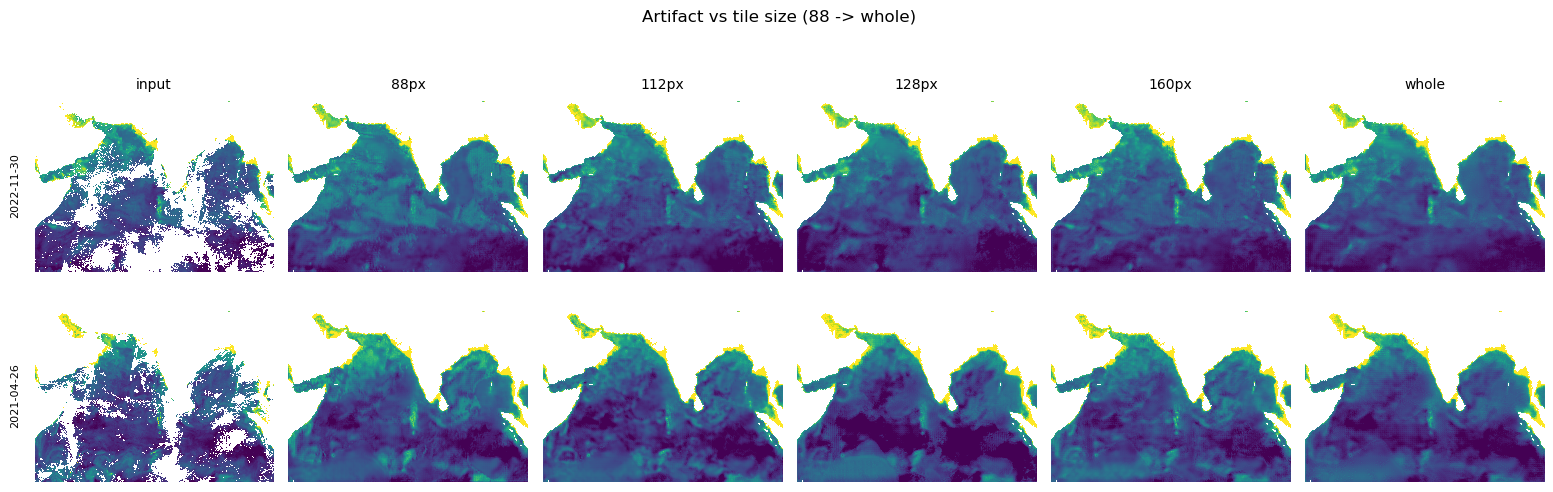

In [11]:
import os, numpy as np, tensorflow as tf, mindthegap as mtg, matplotlib.pyplot as plt, pandas as pd
bpc = mtg.build_pace_channels
WDIR = os.path.expanduser("~/shared-public/mindthegap"); MODELS = f"{WDIR}/models"

z = np.load(f"{WDIR}/cache/io_last730.npz", allow_pickle=True)     # load the IO cube
chl_log = z["chl_log"]; times = z["times"]; LATV = z["LATV"]; LONV = z["LONV"]
ocean = np.isfinite(z["feats"][0]).any(0); T, H, W = chl_log.shape

rng0 = np.random.default_rng(0); perm = rng0.permutation(T); tr = np.zeros(T, bool); tr[perm[:int(0.8*T)]] = True
ch, y, ST, OR = bpc(chl_log, times, tr, n_days=1, cloud_mode="synthetic", coverage=0.2, blob_sigma=12, time_sigma=1.5, seed=0, land=~ocean)
m0, s0 = ST["CHL"]
la = np.deg2rad(LATV)[:,None]; lo = np.deg2rad(LONV)[None,:]
geo = np.stack([np.broadcast_to(np.cos(la)*np.cos(lo),(H,W)), np.broadcast_to(np.cos(la)*np.sin(lo),(H,W)), np.broadcast_to(np.sin(la),(H,W))],-1).astype("float32")
X = np.concatenate([np.stack([ch[k] for k in OR],-1), np.broadcast_to(geo[None],(T,H,W,3))],-1).astype("float32")

sizes = ["88px","112px","128px","160px","whole"]
pred = {k: tf.keras.models.load_model(f"{MODELS}/artUP_{k}_bs12.keras", compile=False).predict(X, batch_size=8, verbose=0)[...,0]*s0+m0 for k in sizes}
adays = [int(np.argmin(np.abs(times - np.datetime64(s)))) for s in ["2022-11-30","2021-04-26"]]
cols = ["input"] + sizes
fig, axes = plt.subplots(len(adays), len(cols), figsize=(2.6*len(cols), 2.6*len(adays)), squeeze=False)
for r, d in enumerate(adays):
    truth = chl_log[d]; loo, hii = np.nanpercentile(truth[ocean][np.isfinite(truth[ocean])],[2,98])
    imgs = [np.where(ocean & np.isfinite(truth), truth, np.nan)] + [np.where(ocean, pred[k][d], np.nan) for k in sizes]
    for c, arr in enumerate(imgs):
        axes[r,c].imshow(arr, cmap="viridis", vmin=loo, vmax=hii, origin="upper"); axes[r,c].axis("off")
        if r==0: axes[r,c].set_title(cols[c], fontsize=10)
    axes[r,0].text(-0.06,0.5,str(pd.to_datetime(times[d]).date()),transform=axes[r,0].transAxes,rotation=90,va="center",ha="right",fontsize=8)
plt.suptitle("Artifact vs tile size (88 -> whole)", y=1.01); plt.tight_layout(); plt.show()


overall held-out MAE (log Chl-a):
    88px: 0.1708
   112px: 0.1481
   128px: 0.1859
   160px: 0.1295
   whole: 0.1684


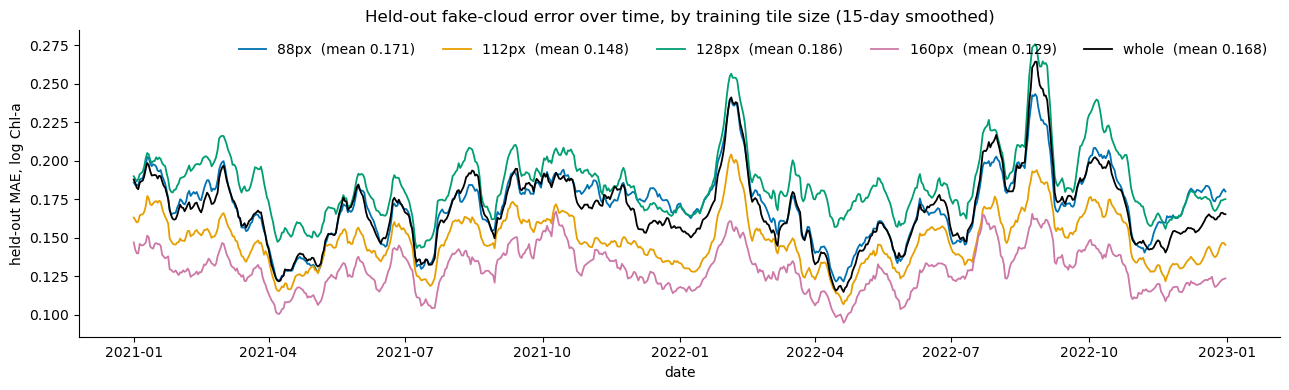

In [12]:
fake = ch["fake_cloud_flag"].astype(bool)

def per_frame_mae(pk):
    out = np.full(T, np.nan)
    for d in range(T):
        held = fake[d] & ocean & np.isfinite(chl_log[d])
        if held.any(): out[d] = np.mean(np.abs(pk[d][held] - chl_log[d][held]))
    return out
mae = {k: per_frame_mae(pred[k]) for k in sizes}

print("overall held-out MAE (log Chl-a):")
for k in sizes: print(f"  {k:>6}: {np.nanmean(mae[k]):.4f}")

colors = {"88px":"#0072B2","112px":"#E69F00","128px":"#009E73","160px":"#CC79A7","whole":"#000000"}
tt = pd.to_datetime(times)
fig, ax = plt.subplots(figsize=(13, 4))
for k in sizes:
    s = pd.Series(mae[k], index=tt).rolling(15, min_periods=1, center=True).mean()
    ax.plot(s.index, s.values, color=colors[k], lw=1.3, label=f"{k}  (mean {np.nanmean(mae[k]):.3f})")
ax.set_ylabel("held-out MAE, log Chl-a"); ax.set_xlabel("date")
ax.set_title("Held-out fake-cloud error over time, by training tile size (15-day smoothed)")
ax.legend(frameon=False, ncol=5); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


In [14]:
H, W = 176, 240
def ntiles(S):
    ys = list(range(0, H-S+1, S)) or [0]; xs = list(range(0, W-S+1, S)) or [0]
    if ys[-1] != H-S: ys.append(H-S)
    if xs[-1] != W-S: xs.append(W-S)
    return len(ys)*len(xs)
for S in [88,112,128,160]:
    n = ntiles(S); print(f"{S}px: {n} tiles -> +{(n*S*S/(H*W)-1)*100:.0f}% overlap")


88px: 6 tiles -> +10% overlap
112px: 6 tiles -> +78% overlap
128px: 4 tiles -> +55% overlap
160px: 4 tiles -> +142% overlap


In [1]:
%%writefile /home/jovyan/shared-public/mindthegap/artifact_worker.py
# One Copernicus artifact-test job per subprocess: read a 4km box, build channels with
# synthetic clouds (same recipe as the IO tile-sweep), train one tile size, save the model.
# Usage: python artifact_worker.py '<job-json>'
import os, sys, json, time, traceback
import numpy as np

WORK = os.path.expanduser("~/shared-public/mindthegap")
CACHE = f"{WORK}/cache"; MODELS = f"{WORK}/models"; FLAGS = f"{WORK}/flags"
for d in (CACHE, MODELS, FLAGS): os.makedirs(d, exist_ok=True)

def label(S): return "whole" if S is None else f"{S}px"

def read_region(cfg):
    import xarray as xr
    lat_lo, lat_hi, lon_lo, lon_hi = cfg["box"]
    nfr = cfg["n_frames"]; comp = cfg.get("composite", 1); src = cfg.get("source", "sourcecoop")
    if src == "sourcecoop":
        import icechunk as ic
        url = "https://data.source.coop/fish-pace/globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"
        storage = ic.http_storage(url); repo = ic.Repository.open(storage)
        containers = repo.config.virtual_chunk_containers or []
        store = ic.Repository.open(storage, authorize_virtual_chunk_access={p: ic.credentials.HttpAccess for p in containers}).readonly_session("main").store
        ds = xr.open_zarr(store, consolidated=False, chunks={})
        def sel(da):
            a = da.sel(lat=slice(lat_hi, lat_lo))
            if a.sizes["lat"] == 0: a = da.sel(lat=slice(lat_lo, lat_hi))
            b = a.sel(lon=slice(lon_lo, lon_hi))
            if b.sizes["lon"] == 0: b = a.sel(lon=slice(lon_hi, lon_lo))
            return b
        reg = sel(ds["CHL"]); flg2d = sel(ds["flags"].isel(time=0))
    else:
        import copernicusmarine
        ds = copernicusmarine.open_dataset(
            dataset_id="cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D",
            variables=["CHL", "flags"],
            minimum_longitude=lon_lo, maximum_longitude=lon_hi,
            minimum_latitude=lat_lo, maximum_latitude=lat_hi,
            start_datetime=cfg.get("start", "2023-06-01"), end_datetime=cfg.get("end", "2024-12-31"))
        ds = ds.rename({c: n for c, n in [("latitude", "lat"), ("longitude", "lon")] if c in ds.coords})
        reg = ds["CHL"]; flg2d = ds["flags"].isel(time=0) if "flags" in ds.data_vars else None
    if comp > 1:
        reg = reg.resample(time=f"{comp}D").mean()
    nlat, nlon = reg.sizes["lat"], reg.sizes["lon"]
    cy = slice(0, nlat - nlat % 8); cx = slice(0, nlon - nlon % 8)
    reg = reg.isel(lat=cy, lon=cx)
    times = reg.time.values; T = reg.sizes["time"]
    keep = slice(max(0, T - nfr), T); reg = reg.isel(time=keep); times = times[keep]; T = reg.sizes["time"]
    H, W = reg.sizes["lat"], reg.sizes["lon"]; LATV = reg.lat.values; LONV = reg.lon.values
    chl_log = np.empty((T, H, W), np.float32)
    for t0 in range(0, T, 20):
        blk = reg.isel(time=slice(t0, t0 + 20)).values
        chl_log[t0:t0 + 20] = np.log(np.where(blk > 0, blk, np.nan)).astype("float32")
        print(f"  read {min(t0 + 20, T)}/{T}", flush=True)
    if flg2d is not None:
        land = (flg2d.isel(lat=cy, lon=cx).values == 1)
    else:
        land = ~np.isfinite(chl_log).any(0)
    return chl_log, times, LATV, LONV, ~land

def geo_full(LATV, LONV, H, W):
    la = np.deg2rad(LATV)[:, None]; lo = np.deg2rad(LONV)[None, :]
    return np.stack([np.broadcast_to(np.cos(la) * np.cos(lo), (H, W)),
                     np.broadcast_to(np.cos(la) * np.sin(lo), (H, W)),
                     np.broadcast_to(np.sin(la), (H, W))], -1).astype("float32")

def main(cfg):
    import tensorflow as tf
    import mindthegap as mtg
    for g in tf.config.list_physical_devices("GPU"):
        tf.config.experimental.set_memory_growth(g, True)
    bpc = mtg.build_pace_channels
    tag = cfg["region_tag"]; blob = cfg["blob"]; seed = cfg.get("seed", 0)
    tile = cfg["tile"]; epochs = cfg.get("epochs", 40); cov = cfg.get("coverage", 0.25)

    npz = f"{CACHE}/{tag}.npz"
    if os.path.exists(npz):
        z = np.load(npz, allow_pickle=True)
        chl_log = z["chl_log"]; times = z["times"]; LATV = z["LATV"]; LONV = z["LONV"]; ocean = z["ocean"]
        print("reused", npz, flush=True)
    else:
        chl_log, times, LATV, LONV, ocean = read_region(cfg)
        np.savez(npz, chl_log=chl_log, times=times, LATV=LATV, LONV=LONV, ocean=ocean)
        print("saved", npz, flush=True)
    T, H, W = chl_log.shape
    covm = np.mean([np.isfinite(chl_log[t])[ocean].mean() for t in range(0, T, max(1, T // 30))])
    print(f"region {H}x{W}, {T} frames | ocean {ocean.mean():.0%} | mean coverage {covm:.0%}", flush=True)

    rng0 = np.random.default_rng(0); perm = rng0.permutation(T); ntr = int(0.8 * T)
    trm = np.zeros(T, bool); trm[perm[:ntr]] = True
    tr = np.where(trm)[0]; val = np.where(~trm)[0]

    ch, y, STATS, ORDER = bpc(chl_log, times, trm, n_days=1, cloud_mode="synthetic",
                              coverage=cov, blob_sigma=blob, time_sigma=1.5, seed=seed, land=~ocean)
    X = np.concatenate([np.stack([ch[k] for k in ORDER], -1),
                        np.broadcast_to(geo_full(LATV, LONV, H, W)[None], (T, H, W, 3))], -1).astype("float32")
    Y = np.stack([np.nan_to_num(y, nan=0.0), ch["fake_cloud_flag"]], -1).astype("float32")
    NC = X.shape[-1]

    mpath = f"{MODELS}/{tag}_{label(tile)}_bs{blob}.keras"
    if os.path.exists(mpath):
        print("model exists, skipping train:", mpath, flush=True); ntiles = 0; secs = 0.0
    else:
        tf.keras.backend.clear_session()
        Xva, Yva = X[val[:16]], Y[val[:16]]
        m = mtg.UNet((None, None, NC)); m.compile("adam", loss=mtg.masked_mse, jit_compile=False)
        es = tf.keras.callbacks.EarlyStopping("val_loss", patience=6, restore_best_weights=True)
        t0 = time.time()
        if tile is None:
            pos = [(0, 0)]
            m.fit(X[tr], Y[tr], batch_size=8, epochs=epochs, validation_data=(Xva, Yva), callbacks=[es], verbose=2)
        else:
            ys = list(range(0, H - tile + 1, tile)) or [0]; xs = list(range(0, W - tile + 1, tile)) or [0]
            if ys[-1] != H - tile: ys.append(H - tile)
            if xs[-1] != W - tile: xs.append(W - tile)
            pos = [(yy, xx) for yy in ys for xx in xs]
            steps = max(1, len(pos) * len(tr) // 8)
            def gen(pos=pos, tile=tile):
                r = np.random.default_rng(tile)
                while True:
                    pairs = [(int(fr), p) for fr in tr for p in pos]; r.shuffle(pairs)
                    for fr, (y0, x0) in pairs:
                        yield X[fr, y0:y0+tile, x0:x0+tile], Y[fr, y0:y0+tile, x0:x0+tile]
            sig = (tf.TensorSpec((tile, tile, NC), tf.float32), tf.TensorSpec((tile, tile, 2), tf.float32))
            dst = tf.data.Dataset.from_generator(gen, output_signature=sig).batch(8).prefetch(2)
            m.fit(dst, steps_per_epoch=steps, epochs=epochs, validation_data=(Xva, Yva), callbacks=[es], verbose=2)
        secs = time.time() - t0; ntiles = len(pos); m.save(mpath)
        print(f"trained {label(tile)} ({ntiles} tiles) in {secs:.0f}s -> {mpath}", flush=True)

    flag = f"{FLAGS}/{cfg['name']}.json"
    json.dump(dict(name=cfg["name"], region_tag=tag, H=int(H), W=int(W), T=int(T),
                   tile=(None if tile is None else int(tile)), ntiles=int(ntiles), blob=int(blob),
                   seconds=float(secs), model=mpath), open(flag, "w"))
    print("wrote flag", flag, flush=True)

if __name__ == "__main__":
    cfg = json.loads(sys.argv[1])
    try:
        main(cfg)
    except Exception:
        traceback.print_exc(); sys.exit(1)


Writing /home/jovyan/shared-public/mindthegap/artifact_worker.py


In [7]:
import os, sys, json, subprocess, importlib

def ensure(mod, spec, extra=()):
    # Workers run under sys.executable; make sure each dependency is importable there.
    try:
        importlib.import_module(mod)
    except ImportError:
        print("installing", spec, "for", sys.executable, flush=True)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *extra, spec], check=True)
        importlib.invalidate_caches(); importlib.import_module(mod)

ensure("mindthegap", "git+https://github.com/SAFS-Varanasi-Internship/mindthegap.git@troy-branch",
       extra=["--force-reinstall", "--no-cache-dir"])
ensure("copernicusmarine", "copernicusmarine")

WORK = os.path.expanduser("~/shared-public/mindthegap")
LOGS = f"{WORK}/logs"; FLAGS = f"{WORK}/flags"
os.makedirs(LOGS, exist_ok=True); os.makedirs(FLAGS, exist_ok=True)
worker = f"{WORK}/artifact_worker.py"

TAG = "copart176x240"
BOX = [6.0, 13.34, 60.0, 70.0]   # lat_lo, lat_hi, lon_lo, lon_hi  (~7.3 x 10 deg -> ~176x240 px at 4km)
SOURCE = "copernicusmarine"      # dense recent daily (needs a cached copernicusmarine.login()); "sourcecoop" needs a matching icechunk
NFR = 365; BLOB = 12; COMPOSITE = 1

jobs = [dict(name=f"{TAG}_{t if t else 'whole'}", region_tag=TAG, box=BOX, n_frames=NFR, blob=BLOB,
             tile=t, epochs=40, seed=0, coverage=0.25, source=SOURCE, composite=COMPOSITE,
             start="2023-06-01", end="2024-12-31")
        for t in [88, 112, 128, None]]

for j in jobs:
    flag = f"{FLAGS}/{j['name']}.json"
    if os.path.exists(flag):
        print("skip (done):", j["name"], "->", json.load(open(flag))); continue
    log = f"{LOGS}/{j['name']}.log"
    print("=== RUN", j["name"], "===", flush=True)
    with open(log, "w") as lf:
        rc = subprocess.run([sys.executable, worker, json.dumps(j)], stdout=lf, stderr=subprocess.STDOUT).returncode
    if os.path.exists(flag):
        print("   ok:", json.load(open(flag)))
    else:
        print(f"   FAILED (rc={rc}); tail of {log}:")
        print("".join(open(log).readlines()[-30:]))


skip (done): copart176x240_88 -> {'name': 'copart176x240_88', 'region_tag': 'copart176x240', 'H': 176, 'W': 240, 'T': 365, 'tile': 88, 'ntiles': 6, 'blob': 12, 'seconds': 251.1363649368286, 'model': '/home/jovyan/shared-public/mindthegap/models/copart176x240_88px_bs12.keras'}
=== RUN copart176x240_112 ===
   ok: {'name': 'copart176x240_112', 'region_tag': 'copart176x240', 'H': 176, 'W': 240, 'T': 365, 'tile': 112, 'ntiles': 6, 'blob': 12, 'seconds': 216.73366475105286, 'model': '/home/jovyan/shared-public/mindthegap/models/copart176x240_112px_bs12.keras'}
=== RUN copart176x240_128 ===
   ok: {'name': 'copart176x240_128', 'region_tag': 'copart176x240', 'H': 176, 'W': 240, 'T': 365, 'tile': 128, 'ntiles': 4, 'blob': 12, 'seconds': 280.98981642723083, 'model': '/home/jovyan/shared-public/mindthegap/models/copart176x240_128px_bs12.keras'}
=== RUN copart176x240_whole ===
   ok: {'name': 'copart176x240_whole', 'region_tag': 'copart176x240', 'H': 176, 'W': 240, 'T': 365, 'tile': None, 'ntiles

2026-08-12 01:24:40.292182: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-12 01:24:40.686816: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.36 = (f32[8,64,176,240]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,12,176,240]{3,2,1,0} %bitcast.688, f32[64,12,3,3]{3,2,1,0} %bitcast.695, f32[64]{0} %bitcast.697), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-net_1/conv2d_1/convolution" source_file="/srv/conda/envs/notebook/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input

loaded: ['88px', '112px', '128px', 'whole']
   tile  held MAE
   88px    0.0965
  112px    0.0910
  128px    0.0864
  whole    0.0974


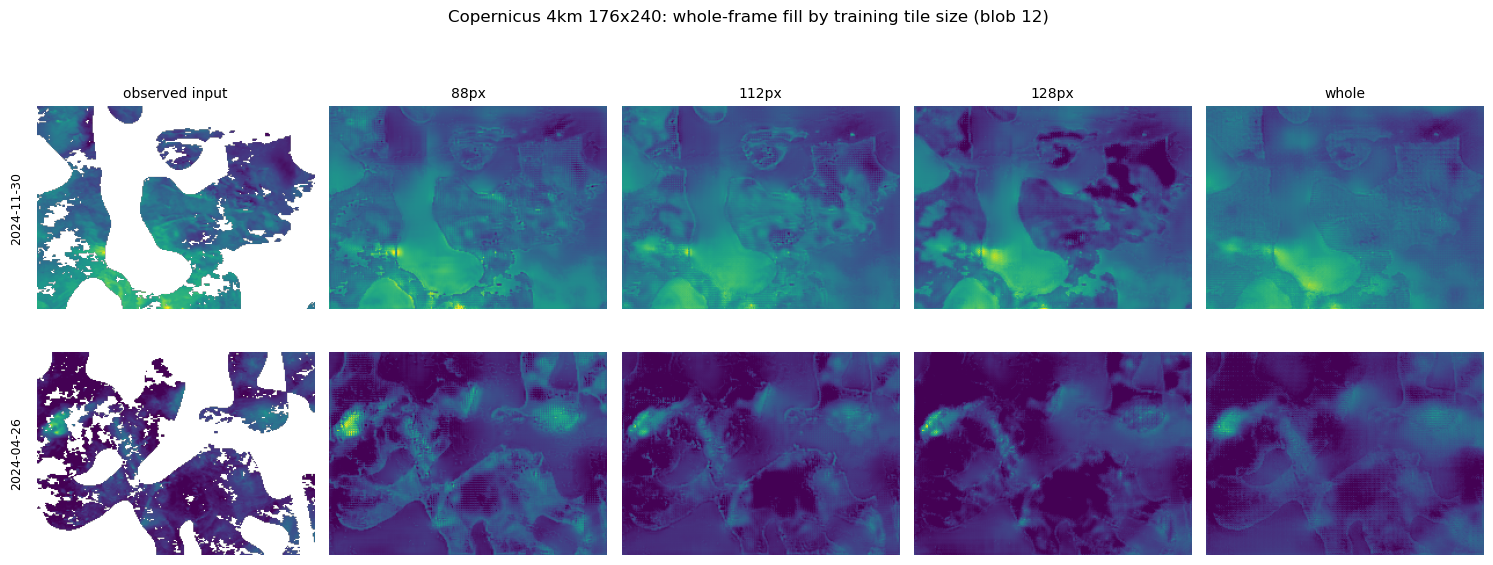

In [7]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf, mindthegap as mtg
WORK = os.path.expanduser("~/shared-public/mindthegap"); CACHE = f"{WORK}/cache"; MODELS = f"{WORK}/models"
bpc = mtg.build_pace_channels
TAG = "copart176x240"; BLOB = 12; SEED = 0; COV = 0.25

z = np.load(f"{CACHE}/{TAG}.npz", allow_pickle=True)
chl_log = z["chl_log"]; times = z["times"]; LATV = z["LATV"]; LONV = z["LONV"]; ocean = z["ocean"]
T, H, W = chl_log.shape
rng0 = np.random.default_rng(0); perm = rng0.permutation(T); ntr = int(0.8 * T)
trm = np.zeros(T, bool); trm[perm[:ntr]] = True; val = np.where(~trm)[0]
ch, y, STATS, ORDER = bpc(chl_log, times, trm, n_days=1, cloud_mode="synthetic",
                          coverage=COV, blob_sigma=BLOB, time_sigma=1.5, seed=SEED, land=~ocean)
Y_MEAN, Y_STD = STATS["CHL"]; fake = ch["fake_cloud_flag"].astype(bool)
la = np.deg2rad(LATV)[:, None]; lo = np.deg2rad(LONV)[None, :]
geo = np.stack([np.broadcast_to(np.cos(la)*np.cos(lo), (H, W)), np.broadcast_to(np.cos(la)*np.sin(lo), (H, W)),
                np.broadcast_to(np.sin(la), (H, W))], -1).astype("float32")
X = np.concatenate([np.stack([ch[k] for k in ORDER], -1), np.broadcast_to(geo[None], (T, H, W, 3))], -1).astype("float32")

SIZES = [88, 112, 128, None]
def lbl(S): return "whole" if S is None else f"{S}px"
pred = {}
for S in SIZES:
    p = f"{MODELS}/{TAG}_{lbl(S)}_bs{BLOB}.keras"
    if not os.path.exists(p): print("missing", p); continue
    m = tf.keras.models.load_model(p, compile=False)
    pred[lbl(S)] = m.predict(X, batch_size=8, verbose=0)[..., 0] * Y_STD + Y_MEAN
    tf.keras.backend.clear_session()
print("loaded:", list(pred))

print(f"{'tile':>7} {'held MAE':>9}")     # accuracy parity: MAE should be flat, the artifact is the only separator
for S in SIZES:
    k = lbl(S)
    if k not in pred: continue
    errs = [np.abs(pred[k][d][h] - chl_log[d][h]).mean()
            for d in val for h in [fake[d] & ocean & np.isfinite(chl_log[d])] if h.any()]
    print(f"{k:>7} {np.mean(errs):>9.4f}")

order = [lbl(S) for S in SIZES if lbl(S) in pred]
days = sorted(val, key=lambda d: int((fake[d] & ocean).sum()), reverse=True)[:2]
fin = chl_log[np.isfinite(chl_log)]; vmin, vmax = np.nanpercentile(fin, [2, 98])
fig, axes = plt.subplots(len(days), len(order)+1, figsize=((len(order)+1)*3.0, len(days)*3.0), squeeze=False)
for i, d in enumerate(days):
    truth = chl_log[d]
    axes[i, 0].imshow(np.where(ocean & np.isfinite(truth) & ~fake[d], truth, np.nan),
                      cmap="viridis", vmin=vmin, vmax=vmax, origin="upper")
    axes[i, 0].set_title("observed input" if i == 0 else "", size=10); axes[i, 0].axis("off")
    axes[i, 0].text(-0.05, 0.5, str(pd.to_datetime(times[d]).date()), transform=axes[i, 0].transAxes,
                    rotation=90, va="center", ha="right", size=9)
    for j, k in enumerate(order):
        axes[i, j+1].imshow(np.where(ocean, pred[k][d], np.nan), cmap="viridis", vmin=vmin, vmax=vmax, origin="upper")
        axes[i, j+1].set_title(k if i == 0 else "", size=10); axes[i, j+1].axis("off")
plt.suptitle(f"Copernicus 4km {H}x{W}: whole-frame fill by training tile size (blob {BLOB})", y=1.01)
plt.tight_layout(); plt.savefig("copart_tilesweep.png", dpi=120, bbox_inches="tight"); plt.show()


In [ ]:
N_DAYS = 1; BATCH = 8; S = 48; STEPS = 300; COVERAGE, BLOB_SIGMA = 0.2, 12
rng0 = np.random.default_rng(0); perm = rng0.permutation(T); ntr = int(0.8*T)
tr = np.zeros(T, bool); tr[perm[:ntr]] = True; va = ~tr
tr_frames = np.where(tr)[0]; vsel = np.where(va)[0][:24]

def geo_full():
    la = np.deg2rad(LATV)[:, None]; lo = np.deg2rad(LONV)[None, :]
    return np.stack([np.broadcast_to(np.cos(la)*np.cos(lo), (H, W)),
                     np.broadcast_to(np.cos(la)*np.sin(lo), (H, W)),
                     np.broadcast_to(np.sin(la), (H, W))], -1).astype("float32")
def grid_positions(Sz):
    ys = list(range(0, H-Sz+1, Sz)) or [0]; xs = list(range(0, W-Sz+1, Sz)) or [0]
    if ys[-1] != H-Sz: ys.append(H-Sz)
    if xs[-1] != W-Sz: xs.append(W-Sz)
    return [(yy, xx) for yy in ys for xx in xs]

ch, y, STATS, ORDER = bpc(chl_log, times, tr, n_days=N_DAYS, cloud_mode="synthetic",
                          coverage=COVERAGE, blob_sigma=BLOB_SIGMA, time_sigma=1.5, seed=0, land=~ocean)
Y_MEAN, Y_STD = STATS["CHL"]; fake = ch["fake_cloud_flag"].astype(bool)
Y = np.stack([np.nan_to_num(y, nan=0.0), ch["fake_cloud_flag"]], -1).astype("float32")
base = np.stack([ch[k] for k in ORDER], -1).astype("float32")
Xg = np.concatenate([base, np.broadcast_to(geo_full()[None], (T, H, W, 3))], -1).astype("float32")
pos = grid_positions(S)

def train_or_load(Xin, tag, seed):
    path = f"{MODEL_DIR}/geotest_{S}px_{tag}_s{seed}.keras"
    if os.path.exists(path):
        print("load", tag, seed); return tf.keras.models.load_model(path, compile=False)
    tf.keras.backend.clear_session(); tf.keras.utils.set_random_seed(seed)
    m = mtg.UNet((None, None, Xin.shape[-1])); m.compile("adam", loss=mtg.masked_mse, jit_compile=False)
    es = tf.keras.callbacks.EarlyStopping("val_loss", patience=6, restore_best_weights=True)
    def gen():
        r = np.random.default_rng(seed)
        while True:
            pr = [(int(fr), p) for fr in tr_frames for p in pos]; r.shuffle(pr)
            for fr, (y0, x0) in pr:
                yield Xin[fr, y0:y0+S, x0:x0+S], Y[fr, y0:y0+S, x0:x0+S]
    sig = (tf.TensorSpec((S, S, Xin.shape[-1]), tf.float32), tf.TensorSpec((S, S, 2), tf.float32))
    dst = tf.data.Dataset.from_generator(gen, output_signature=sig).batch(BATCH).prefetch(2)
    print("=== train", tag, seed, "===", flush=True)
    m.fit(dst, steps_per_epoch=STEPS, epochs=40, validation_data=(Xin[vsel], Y[vsel]), callbacks=[es], verbose=2)
    m.save(path); print("saved", path); return m

runs = {}
for tag, Xin in [("geo", Xg), ("nogeo", base)]:
    for seed in [0, 1]:
        m = train_or_load(Xin, tag, seed)
        runs[f"{tag} s{seed}"] = m.predict(Xin, batch_size=BATCH, verbose=0)[..., 0] * Y_STD + Y_MEAN
print("done:", list(runs))


load geo 0
load geo 1
load nogeo 0


2026-08-10 21:11:50.355082: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.36 = (f32[8,64,176,240]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,9,176,240]{3,2,1,0} %bitcast.688, f32[64,9,3,3]{3,2,1,0} %bitcast.695, f32[64]{0} %bitcast.697), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-net_1/conv2d_1/convolution" source_file="/srv/conda/envs/notebook/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-08-10 21:11:50.415154: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potential

load nogeo 1
done: ['geo s0', 'geo s1', 'nogeo s0', 'nogeo s1']


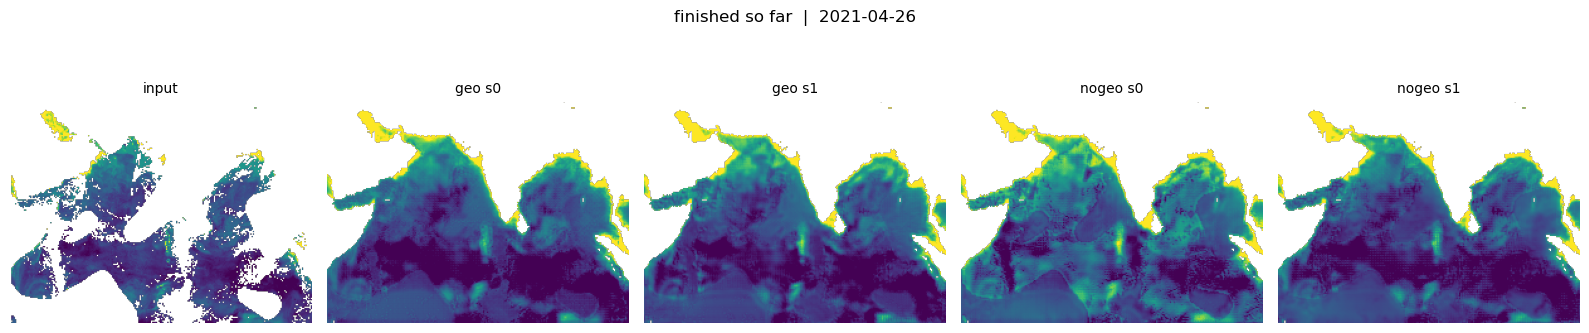

In [ ]:
d = int(np.argmin(np.abs(times - np.datetime64("2021-04-26"))))
truth = chl_log[d]; lo, hi = np.nanpercentile(truth[ocean][np.isfinite(truth[ocean])], [2, 98])
panels = [("input", np.where(ocean & np.isfinite(truth) & ~fake[d], truth, np.nan))]
panels += [(k, np.where(ocean, runs[k][d], np.nan)) for k in runs]   # whatever finished so far
fig, ax = plt.subplots(1, len(panels), figsize=(3.2*len(panels), 3.4))
for a, (ttl, arr) in zip(ax, panels):
    a.imshow(arr, cmap="viridis", vmin=lo, vmax=hi, origin="upper"); a.set_title(ttl, size=10); a.axis("off")
plt.suptitle(f"finished so far  |  {str(pd.to_datetime(times[d]).date())}", y=1.05)
plt.tight_layout(); plt.show()


In [7]:
import sys, subprocess, importlib
def ensure(mod, spec, extra=()):
    try:
        importlib.import_module(mod)
    except ImportError:
        print("installing", spec, "...", flush=True)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *extra, spec], check=True)
        importlib.invalidate_caches(); importlib.import_module(mod)
ensure("mindthegap", "git+https://github.com/SAFS-Varanasi-Internship/mindthegap.git@troy-branch",
       ["--force-reinstall", "--no-cache-dir"])
ensure("copernicusmarine", "copernicusmarine")
print("deps ready")


installing copernicusmarine ...


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xmip 0.7.2 requires xgcm<0.7.0, but you have xgcm 0.9.0 which is incompatible.


deps ready


In [8]:
import os, numpy as np, copernicusmarine
WORK = os.path.expanduser("~/shared-public/mindthegap"); CACHE = f"{WORK}/cache"; os.makedirs(CACHE, exist_ok=True)
TAG = "copoman176x240"
BOX = [14.0, 21.34, 55.0, 65.0]           # lat_lo, lat_hi, lon_lo, lon_hi : Oman/Dhofar upwelling, coastline + strong blooms
START, END = "2024-06-01", "2024-12-31"
npz = f"{CACHE}/{TAG}.npz"

if os.path.exists(npz):
    z = np.load(npz, allow_pickle=True); print("cache exists:", npz, "->", z["chl_log"].shape, "| ocean", f"{z['ocean'].mean():.0%}")
else:
    lat_lo, lat_hi, lon_lo, lon_hi = BOX
    print("opening Copernicus Marine (fails fast here if not logged in)...", flush=True)
    ds = copernicusmarine.open_dataset(
        dataset_id="cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D",
        variables=["CHL", "flags"],
        minimum_longitude=lon_lo, maximum_longitude=lon_hi,
        minimum_latitude=lat_lo, maximum_latitude=lat_hi,
        start_datetime=START, end_datetime=END)
    ds = ds.rename({c: n for c, n in [("latitude", "lat"), ("longitude", "lon")] if c in ds.coords})
    reg = ds["CHL"]; flg2d = ds["flags"].isel(time=0) if "flags" in ds.data_vars else None
    nlat, nlon = reg.sizes["lat"], reg.sizes["lon"]
    cy = slice(0, nlat - nlat % 8); cx = slice(0, nlon - nlon % 8)
    reg = reg.isel(lat=cy, lon=cx)
    times = reg.time.values; T, H, W = reg.sizes["time"], reg.sizes["lat"], reg.sizes["lon"]
    LATV, LONV = reg.lat.values, reg.lon.values
    print(f"region {H}x{W}, {T} frames -> reading", flush=True)
    chl_log = np.empty((T, H, W), np.float32)
    for t0 in range(0, T, 50):
        blk = reg.isel(time=slice(t0, t0 + 50)).values
        chl_log[t0:t0 + 50] = np.log(np.where(blk > 0, blk, np.nan)).astype("float32")
        print(f"  read {min(t0 + 50, T)}/{T}", flush=True)
    ocean = (flg2d.isel(lat=cy, lon=cx).values != 1) if flg2d is not None else np.isfinite(chl_log).any(0)
    np.savez(npz, chl_log=chl_log, times=times, LATV=LATV, LONV=LONV, ocean=ocean)
    covm = np.mean([np.isfinite(chl_log[t])[ocean].mean() for t in range(0, T, max(1, T // 30))])
    print(f"saved {npz} | ocean {ocean.mean():.0%} | mean coverage {covm:.0%}")


opening Copernicus Marine (fails fast here if not logged in)...


INFO - 2026-08-12T04:31:06Z - Selected dataset version: "202603"
INFO - 2026-08-12T04:31:06Z - Selected dataset part: "default"


region 176x240, 214 frames -> reading
  read 50/214
  read 100/214
  read 150/214
  read 200/214
  read 214/214
saved /home/jovyan/shared-public/mindthegap/cache/copoman176x240.npz | ocean 87% | mean coverage 46%


In [9]:
import os, sys, json, subprocess, importlib

def ensure(mod, spec, extra=()):
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *extra, spec], check=True)
        importlib.invalidate_caches(); importlib.import_module(mod)
ensure("mindthegap", "git+https://github.com/SAFS-Varanasi-Internship/mindthegap.git@troy-branch",
       extra=["--force-reinstall", "--no-cache-dir"])
ensure("copernicusmarine", "copernicusmarine")

WORK = os.path.expanduser("~/shared-public/mindthegap")
LOGS = f"{WORK}/logs"; FLAGS = f"{WORK}/flags"
os.makedirs(LOGS, exist_ok=True); os.makedirs(FLAGS, exist_ok=True)
worker = f"{WORK}/artifact_worker.py"

TAG = "copoman176x240"
BOX = [14.0, 21.34, 55.0, 65.0]
jobs = [dict(name=f"{TAG}_{t if t else 'whole'}", region_tag=TAG, box=BOX, n_frames=365, blob=12,
             tile=t, epochs=40, seed=0, coverage=0.25, source="copernicusmarine", composite=1,
             start="2024-06-01", end="2024-12-31")
        for t in [88, 112, 128, None]]

for j in jobs:
    flag = f"{FLAGS}/{j['name']}.json"
    if os.path.exists(flag):
        print("skip (done):", j["name"], "->", json.load(open(flag))); continue
    log = f"{LOGS}/{j['name']}.log"
    print("=== RUN", j["name"], "===", flush=True)
    with open(log, "w") as lf:
        rc = subprocess.run([sys.executable, worker, json.dumps(j)], stdout=lf, stderr=subprocess.STDOUT).returncode
    if os.path.exists(flag):
        print("   ok:", json.load(open(flag)))
    else:
        print(f"   FAILED (rc={rc}); tail of {log}:")
        print("".join(open(log).readlines()[-30:]))


=== RUN copoman176x240_88 ===
   ok: {'name': 'copoman176x240_88', 'region_tag': 'copoman176x240', 'H': 176, 'W': 240, 'T': 214, 'tile': 88, 'ntiles': 6, 'blob': 12, 'seconds': 121.17679643630981, 'model': '/home/jovyan/shared-public/mindthegap/models/copoman176x240_88px_bs12.keras'}
=== RUN copoman176x240_112 ===
   ok: {'name': 'copoman176x240_112', 'region_tag': 'copoman176x240', 'H': 176, 'W': 240, 'T': 214, 'tile': 112, 'ntiles': 6, 'blob': 12, 'seconds': 90.68417191505432, 'model': '/home/jovyan/shared-public/mindthegap/models/copoman176x240_112px_bs12.keras'}
=== RUN copoman176x240_128 ===
   ok: {'name': 'copoman176x240_128', 'region_tag': 'copoman176x240', 'H': 176, 'W': 240, 'T': 214, 'tile': 128, 'ntiles': 4, 'blob': 12, 'seconds': 131.02811431884766, 'model': '/home/jovyan/shared-public/mindthegap/models/copoman176x240_128px_bs12.keras'}
=== RUN copoman176x240_whole ===
   ok: {'name': 'copoman176x240_whole', 'region_tag': 'copoman176x240', 'H': 176, 'W': 240, 'T': 214, 'ti

2026-08-14 15:35:41.807347: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-14 15:35:42.475305: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.36 = (f32[8,64,176,240]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,12,176,240]{3,2,1,0} %bitcast.688, f32[64,12,3,3]{3,2,1,0} %bitcast.695, f32[64]{0} %bitcast.697), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-net_1/conv2d_1/convolution" source_file="/srv/conda/envs/notebook/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input

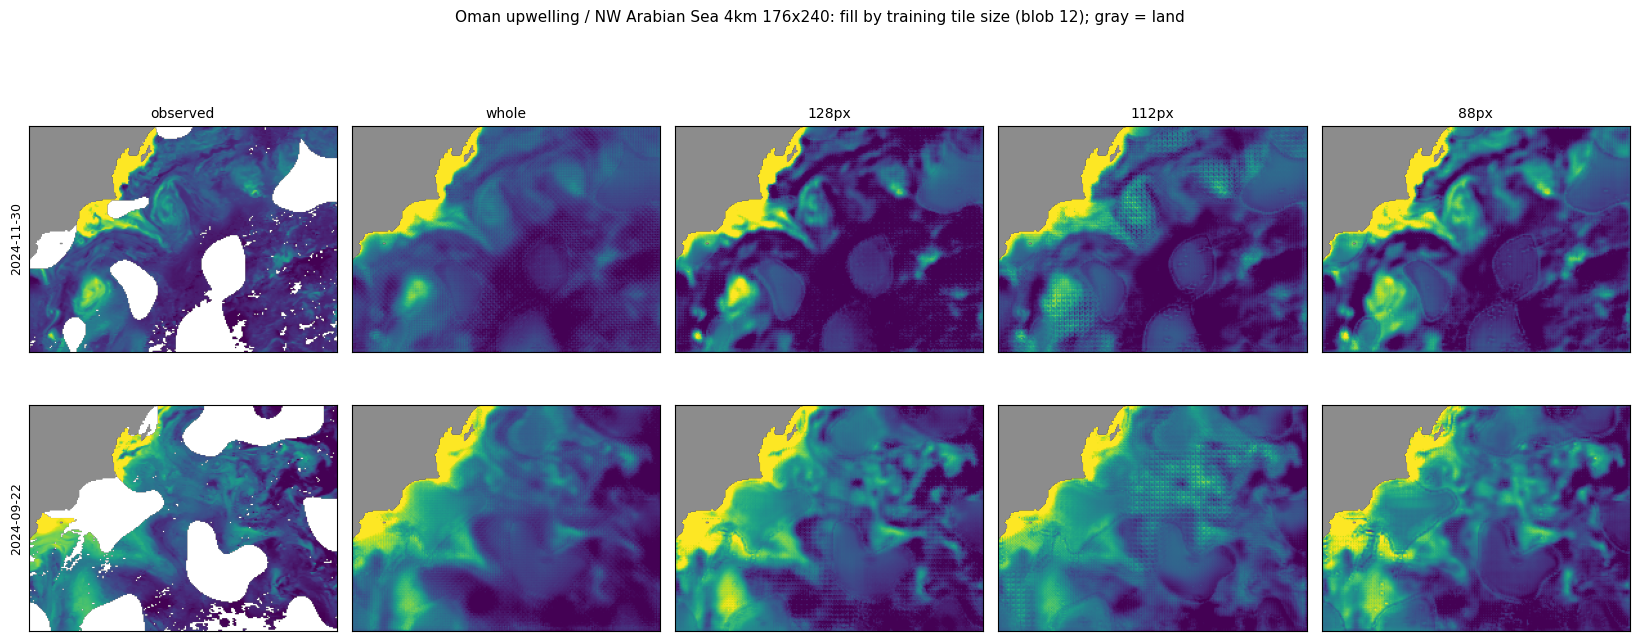

In [5]:
import os, numpy as np, matplotlib.pyplot as plt, pandas as pd, mindthegap as mtg, tensorflow as tf
WORK = os.path.expanduser("~/shared-public/mindthegap"); CACHE = f"{WORK}/cache"; MODELS = f"{WORK}/models"
bpc = mtg.build_pace_channels
TAG = "copoman176x240"; BLOB = 12; SEED = 0; COV = 0.25

z = np.load(f"{CACHE}/{TAG}.npz", allow_pickle=True)
chl_log = z["chl_log"]; times = z["times"]; LATV = z["LATV"]; LONV = z["LONV"]; ocean = z["ocean"]
T, H, W = chl_log.shape
rng0 = np.random.default_rng(0); perm = rng0.permutation(T); ntr = int(0.8*T)
trm = np.zeros(T, bool); trm[perm[:ntr]] = True; val = np.where(~trm)[0]
ch, y, STATS, ORDER = bpc(chl_log, times, trm, n_days=1, cloud_mode="synthetic",
                          coverage=COV, blob_sigma=BLOB, time_sigma=1.5, seed=SEED, land=~ocean)
Y_MEAN, Y_STD = STATS["CHL"]; fake = ch["fake_cloud_flag"].astype(bool)
la = np.deg2rad(LATV)[:, None]; lo = np.deg2rad(LONV)[None, :]
geo = np.stack([np.broadcast_to(np.cos(la)*np.cos(lo),(H,W)), np.broadcast_to(np.cos(la)*np.sin(lo),(H,W)),
                np.broadcast_to(np.sin(la),(H,W))], -1).astype("float32")
X = np.concatenate([np.stack([ch[k] for k in ORDER],-1), np.broadcast_to(geo[None],(T,H,W,3))],-1).astype("float32")

def lbl(S): return "whole" if S is None else f"{S}px"
pred = {}
for S in [None, 128, 112, 88]:
    p = f"{MODELS}/{TAG}_{lbl(S)}_bs{BLOB}.keras"
    if not os.path.exists(p): print("missing", p); continue
    m = tf.keras.models.load_model(p, compile=False)
    pred[lbl(S)] = (m.predict(X, batch_size=8, verbose=0)[..., 0] * Y_STD + Y_MEAN).astype("float32")
    tf.keras.backend.clear_session()

cov = np.array([np.isfinite(chl_log[d])[ocean].mean() for d in val])
days = [int(val[i]) for i in np.argsort(cov)[::-1][:2]]        # two clearest val days
origin = "upper" if LATV[0] > LATV[-1] else "lower"
ext = [float(LONV.min()), float(LONV.max()), float(LATV.min()), float(LATV.max())]
land_rgba = np.zeros((H, W, 4)); land_rgba[~ocean] = [0.55, 0.55, 0.55, 1.0]
cols = [k for k in ["whole", "128px", "112px", "88px"] if k in pred]

fig, axes = plt.subplots(len(days), 1+len(cols), figsize=((1+len(cols))*3.3, len(days)*3.4), squeeze=False)
for r, d in enumerate(days):
    truth = chl_log[d]; vmin, vmax = np.nanpercentile(truth[ocean & np.isfinite(truth)], [3, 97])
    obsf = np.where(ocean & np.isfinite(truth) & ~fake[d], truth, np.nan)
    panels = [("observed", obsf)] + [(k, np.where(ocean, pred[k][d], np.nan)) for k in cols]
    for c, (ttl, arr) in enumerate(panels):
        ax = axes[r, c]
        ax.imshow(arr, cmap="viridis", vmin=vmin, vmax=vmax, extent=ext, origin=origin)
        ax.imshow(land_rgba, extent=ext, origin=origin)
        if r == 0: ax.set_title(ttl, size=10)
        ax.set_xticks([]); ax.set_yticks([])
    axes[r, 0].set_ylabel(str(pd.to_datetime(times[d]).date()), size=9)
plt.suptitle(f"Oman upwelling / NW Arabian Sea 4km {H}x{W}: fill by training tile size (blob {BLOB}); gray = land",
             y=1.02, size=11)
plt.tight_layout(); plt.savefig("copoman_fills.png", dpi=130, bbox_inches="tight"); plt.show()


channel order: ['sin_time', 'cos_time', 'masked_CHL', 'prev1_CHL', 'next1_CHL', 'land_flag', 'real_cloud_flag', 'valid_CHL_flag', 'fake_cloud_flag']
current-day 'masked_CHL' present: True at index 2

   tile  MAE observed  MAE held-out   (loss trains held-out only)
  whole         0.218         0.299
  128px         0.309         0.291
  112px         0.279         0.361
   88px         0.357         0.319


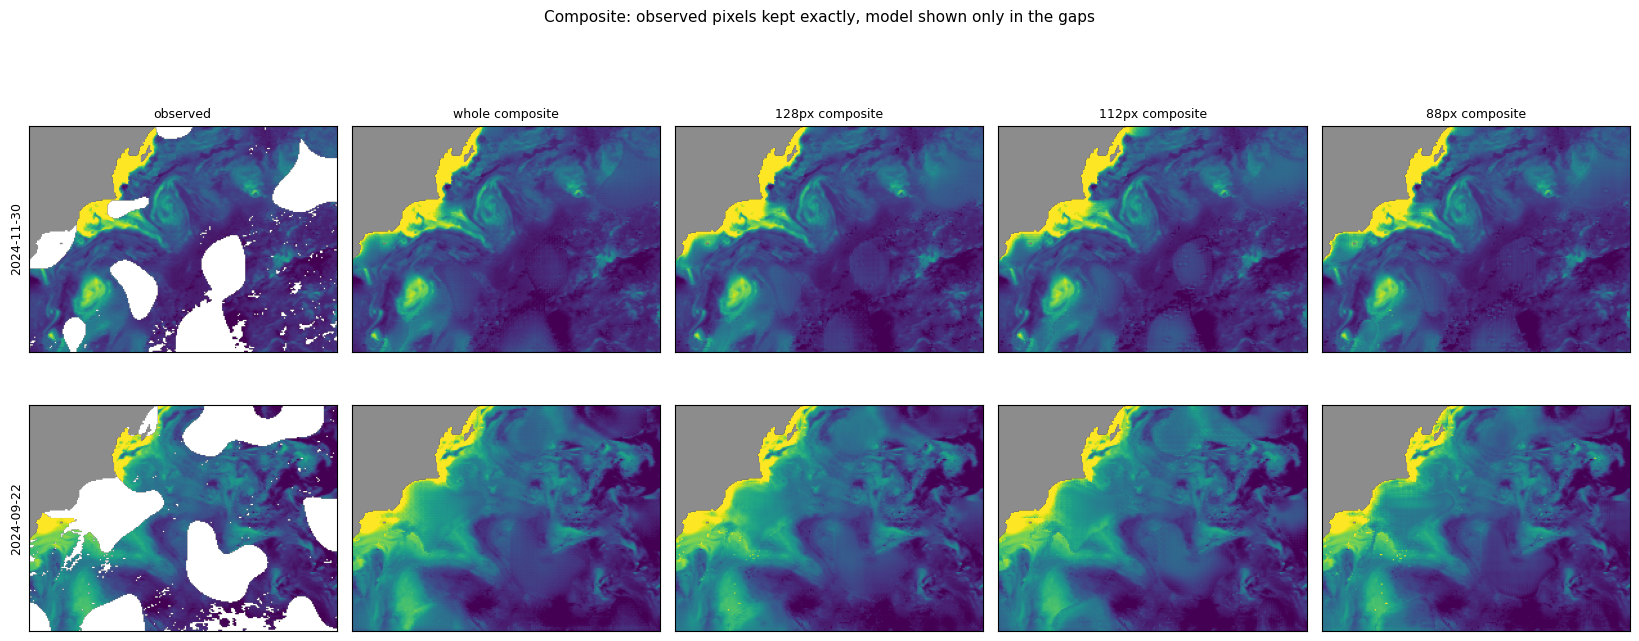

In [6]:
import os, numpy as np, matplotlib.pyplot as plt, pandas as pd, mindthegap as mtg, tensorflow as tf
WORK = os.path.expanduser("~/shared-public/mindthegap"); CACHE = f"{WORK}/cache"; MODELS = f"{WORK}/models"
bpc = mtg.build_pace_channels
TAG = "copoman176x240"; BLOB = 12; SEED = 0; COV = 0.25

z = np.load(f"{CACHE}/{TAG}.npz", allow_pickle=True)
chl_log = z["chl_log"]; times = z["times"]; LATV = z["LATV"]; LONV = z["LONV"]; ocean = z["ocean"]
T, H, W = chl_log.shape
rng0 = np.random.default_rng(0); perm = rng0.permutation(T); ntr = int(0.8*T)
trm = np.zeros(T, bool); trm[perm[:ntr]] = True; val = np.where(~trm)[0]
ch, y, STATS, ORDER = bpc(chl_log, times, trm, n_days=1, cloud_mode="synthetic",
                          coverage=COV, blob_sigma=BLOB, time_sigma=1.5, seed=SEED, land=~ocean)
Y_MEAN, Y_STD = STATS["CHL"]; fake = ch["fake_cloud_flag"].astype(bool)
la = np.deg2rad(LATV)[:, None]; lo = np.deg2rad(LONV)[None, :]
geo = np.stack([np.broadcast_to(np.cos(la)*np.cos(lo),(H,W)), np.broadcast_to(np.cos(la)*np.sin(lo),(H,W)),
                np.broadcast_to(np.sin(la),(H,W))], -1).astype("float32")
X = np.concatenate([np.stack([ch[k] for k in ORDER],-1), np.broadcast_to(geo[None],(T,H,W,3))],-1).astype("float32")

print("channel order:", ORDER)
print("current-day 'masked_CHL' present:", "masked_CHL" in ORDER, "at index", ORDER.index("masked_CHL"))

def lbl(S): return "whole" if S is None else f"{S}px"
pred = {}
for S in [None, 128, 112, 88]:
    p = f"{MODELS}/{TAG}_{lbl(S)}_bs{BLOB}.keras"
    if not os.path.exists(p): continue
    m = tf.keras.models.load_model(p, compile=False)
    pred[lbl(S)] = (m.predict(X, batch_size=8, verbose=0)[..., 0]*Y_STD+Y_MEAN).astype("float32")
    tf.keras.backend.clear_session()

print(f"\n{'tile':>7} {'MAE observed':>13} {'MAE held-out':>13}   (loss trains held-out only)")
for k in pred:
    eo = [np.abs(pred[k][d][mo]-chl_log[d][mo]).mean() for d in val
          for mo in [ocean & np.isfinite(chl_log[d]) & ~fake[d]] if mo.any()]
    ef = [np.abs(pred[k][d][mf]-chl_log[d][mf]).mean() for d in val
          for mf in [ocean & np.isfinite(chl_log[d]) &  fake[d]] if mf.any()]
    print(f"{k:>7} {np.mean(eo):>13.3f} {np.mean(ef):>13.3f}")

cov = np.array([np.isfinite(chl_log[d])[ocean].mean() for d in val])
days = [int(val[i]) for i in np.argsort(cov)[::-1][:2]]
origin = "upper" if LATV[0] > LATV[-1] else "lower"
ext = [float(LONV.min()), float(LONV.max()), float(LATV.min()), float(LATV.max())]
land_rgba = np.zeros((H, W, 4)); land_rgba[~ocean] = [0.55, 0.55, 0.55, 1.0]
cols = [k for k in ["whole", "128px", "112px", "88px"] if k in pred]
fig, axes = plt.subplots(len(days), 1+len(cols), figsize=((1+len(cols))*3.3, len(days)*3.4), squeeze=False)
for r, d in enumerate(days):
    truth = chl_log[d]; vmin, vmax = np.nanpercentile(truth[ocean & np.isfinite(truth)], [3, 97])
    keep = ocean & np.isfinite(truth) & ~fake[d]                     # pixels we actually observed
    panels = [("observed", np.where(keep, truth, np.nan))]
    panels += [(k + " composite", np.where(keep, truth, np.where(ocean, pred[k][d], np.nan))) for k in cols]
    for c, (ttl, arr) in enumerate(panels):
        ax = axes[r, c]
        ax.imshow(arr, cmap="viridis", vmin=vmin, vmax=vmax, extent=ext, origin=origin)
        ax.imshow(land_rgba, extent=ext, origin=origin)
        if r == 0: ax.set_title(ttl, size=9)
        ax.set_xticks([]); ax.set_yticks([])
    axes[r, 0].set_ylabel(str(pd.to_datetime(times[d]).date()), size=9)
plt.suptitle("Composite: observed pixels kept exactly, model shown only in the gaps", y=1.02, size=11)
plt.tight_layout(); plt.savefig("copoman_composite.png", dpi=130, bbox_inches="tight"); plt.show()


In [ ]:
mw = train_at(None)
pw = mw.predict(X, batch_size=BATCH, verbose=0)[..., 0] * Y_STD + Y_MEAN
d = int(sorted(val, key=lambda dd: int((fake[dd] & ocean).sum()), reverse=True)[0])
plt.figure(figsize=(5, 4)); plt.imshow(np.where(ocean, pw[d], np.nan), cmap="viridis")
plt.title("whole-frame, retrained"); plt.axis("off"); plt.show()


Epoch 1/40
73/73 - 20s - 269ms/step - loss: 0.3002 - mae: 1.0093 - val_loss: 0.3287 - val_mae: 0.9324
Epoch 2/40


KeyboardInterrupt: 

## Train one model per tile size (grid tiling, constant data density)

Each frame is tiled into a grid of chunks that cover the whole frame, and one epoch is a single pass over all
of those chunks. So every tile size trains on the same total pixels the same number of times; the only thing
that changes is how finely the frame is chopped, from 1 chunk (the whole frame, as in notebook 10) down to
many small chunks. Edge chunks shift inward to stay on the frame, so the grid always covers everything. For
now every model predicts the whole frame in one pass, which isolates whether the training chunk size alone
causes the smudging. Tiled inference is the quick follow-up.

In [ ]:
SIZES = [None, 88, 64, 48, 32]           # None = whole frame; smaller = more chunks covering the same frame
def label(S): return "whole" if S is None else f"{S}px"

def grid_positions(S):
    ys = list(range(0, H - S + 1, S)) or [0]; xs = list(range(0, W - S + 1, S)) or [0]
    if ys[-1] != H - S: ys.append(H - S)
    if xs[-1] != W - S: xs.append(W - S)
    return [(yy, xx) for yy in ys for xx in xs]

def train_at(S):
    pos = [(0, 0)] if S is None else grid_positions(S)
    path = f"{MODEL_DIR}/tilesweep_grid_{H}x{W}_bs{BLOB_SIGMA}_{label(S)}.keras"
    if os.path.exists(path):
        print(f"  {label(S):>6}  {len(pos):>3} tiles  load")
        return tf.keras.models.load_model(path, compile=False), 0.0, len(pos)
    m = mtg.UNet((None, None, NC)); m.compile("adam", loss=mtg.masked_mse, jit_compile=False)
    t0 = time.time()
    if S is None:
        m.fit(X[tr], Y[tr], batch_size=BATCH, epochs=EPOCHS, verbose=0)
    else:
        steps = max(1, len(pos) * len(tr_frames) // BATCH)     # one epoch = one full pass over the whole domain
        def gen(S=S, pos=pos):
            r = np.random.default_rng(S)
            while True:
                pairs = [(int(fr), p) for fr in tr_frames for p in pos]; r.shuffle(pairs)
                for fr, (y0, x0) in pairs:
                    yield X[fr, y0:y0+S, x0:x0+S], Y[fr, y0:y0+S, x0:x0+S]
        sig = (tf.TensorSpec((S, S, NC), tf.float32), tf.TensorSpec((S, S, 2), tf.float32))
        dst = tf.data.Dataset.from_generator(gen, output_signature=sig).batch(BATCH).prefetch(2)
        m.fit(dst, steps_per_epoch=steps, epochs=EPOCHS, verbose=0)
    dt = time.time() - t0; m.save(path)
    print(f"  {label(S):>6}  {len(pos):>3} tiles  trained in {dt:5.0f}s")
    return m, dt, len(pos)

models, pred, train_s, ntiles = {}, {}, {}, {}
for S in SIZES:
    m, dt, nt = train_at(S); k = label(S)
    models[k] = m; train_s[k] = dt; ntiles[k] = nt
    pred[k] = m.predict(X, batch_size=BATCH, verbose=0)[..., 0] * Y_STD + Y_MEAN   # whole-frame inference
print("done:", list(pred))

In [ ]:
pred = {"whole": pw}
for S in SIZES[1:]:
    print("=== training", label(S), "===", flush=True)
    pred[label(S)] = train_at(S).predict(X, batch_size=BATCH, verbose=0)[..., 0] * Y_STD + Y_MEAN
print("done")


In [ ]:
pred["32px"] = train_at(32).predict(X, batch_size=BATCH, verbose=0)[..., 0] * Y_STD + Y_MEAN
print("done 32px")


## Visual: the same big-gap day filled at each tile size

One high-gap day, filled by every tile size side by side, plus the observed field. Watch the gap interiors go
from flat (small tiles) to structured (large tiles), if that is what the metric shows.

In [ ]:
d = int(sorted(val, key=lambda dd: int((fake[dd] & ocean).sum()), reverse=True)[0])
truth = chl_log[d]
lo, hi = np.nanpercentile(truth[ocean][np.isfinite(truth[ocean])], [2, 98])
panels = [("observed (input)", np.where(ocean & np.isfinite(truth) & ~fake[d], truth, np.nan))]
panels += [(label(S), np.where(ocean, pred[label(S)][d], np.nan)) for S in SIZES]
n = len(panels); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 4.0, nrow * 3.0), squeeze=False)
for ax, (ttl, arr) in zip(axes.ravel(), panels):
    ax.imshow(arr, cmap="viridis", vmin=lo, vmax=hi, origin="upper"); ax.set_title(ttl, size=11); ax.axis("off")
for ax in axes.ravel()[n:]: ax.axis("off")
plt.suptitle(f"IO.zarr {str(pd.to_datetime(times[d]).date())}  |  fill by training tile size", y=1.01)
save_png("tilesweep_fills.png", dpi=120, bbox_inches="tight"); plt.show()

In [ ]:
days = sorted(val, key=lambda dd: int((fake[dd] & ocean).sum()), reverse=True)[:12]
mkeys = [label(S) for S in SIZES]                 # whole, 88px, 64px, 48px, 32px
cols = ["input"] + mkeys
fig, axes = plt.subplots(len(days), len(cols), figsize=(2.6*len(cols), 2.4*len(days)), squeeze=False)
for r, d in enumerate(days):
    truth = chl_log[d]
    lo, hi = np.nanpercentile(truth[ocean][np.isfinite(truth[ocean])], [2, 98])
    imgs = [np.where(ocean & np.isfinite(truth) & ~fake[d], truth, np.nan)]
    imgs += [np.where(ocean, pred[k][d], np.nan) for k in mkeys]
    for c, arr in enumerate(imgs):
        axes[r, c].imshow(arr, cmap="viridis", vmin=lo, vmax=hi, origin="upper"); axes[r, c].axis("off")
        if r == 0: axes[r, c].set_title(cols[c], fontsize=11)
    axes[r, 0].text(-0.06, 0.5, str(pd.to_datetime(times[d]).date()), transform=axes[r, 0].transAxes,
                    rotation=90, va="center", ha="right", fontsize=8)
plt.suptitle("Fill by training tile size across 12 days", y=1.005)
plt.tight_layout(); plt.show()


In [ ]:
T = chl_log.shape[0]
filled_log = None
for _src in [os.path.expanduser("~/shared/mind_the_chl_gap/IO.zarr"),
             "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/IO.zarr"]:
    try:
        fds = xr.open_zarr(_src).isel(time=slice(-T, None))
        fnl, fnw = fds.sizes["lat"], fds.sizes["lon"]
        fds = fds.isel(lat=slice(0, fnl - fnl % 8), lon=slice(0, fnw - fnw % 8))
        _gf = fds["CHL_cmes-gapfree"].values.astype("float32")
        filled_log = np.log(np.where(_gf > 0, _gf, np.nan)).astype("float32")
        print("loaded L4 from", _src); break
    except Exception as e:
        print("no L4 from", _src, "-", repr(e)[:90])

d = int(sorted(val, key=lambda dd: int((fake[dd] & ocean).sum()), reverse=True)[0])
def plot4(k, d):
    truth = chl_log[d]
    lo, hi = np.nanpercentile(truth[ocean][np.isfinite(truth[ocean])], [2, 98])
    cop = np.where(ocean, filled_log[d], np.nan) if filled_log is not None else np.full_like(truth, np.nan)
    panels = [("observed", np.where(ocean & np.isfinite(truth) & ~fake[d], truth, np.nan), lo, hi, "viridis"),
              (f"predicted ({k})", np.where(ocean, pred[k][d], np.nan), lo, hi, "viridis"),
              ("observed - predicted", np.where(ocean & np.isfinite(truth), truth - pred[k][d], np.nan), -1, 1, "RdBu"),
              ("Copernicus L4 gap-free", cop, lo, hi, "viridis")]
    fig, ax = plt.subplots(1, 4, figsize=(18, 4))
    for a, (ttl, arr, l, h, cm) in zip(ax, panels):
        im = a.imshow(arr, vmin=l, vmax=h, cmap=cm, origin="upper"); a.set_title(ttl, size=11); a.axis("off")
        fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)
    fig.suptitle(f"IO.zarr {str(pd.to_datetime(times[d]).date())}  |  {k}", y=1.02)
    plt.tight_layout(); plt.show()

for k in ["whole", label(SIZES[-1])]:      # whole-frame vs smallest tile
    plot4(k, d)


In [ ]:
mkeys = [label(S) for S in SIZES if label(S) in pred]   # only trained sizes
days = sorted(val, key=lambda dd: int((fake[dd] & ocean).sum()), reverse=True)[:12]
cols = ["input"] + mkeys
fig, axes = plt.subplots(len(days), len(cols), figsize=(2.6*len(cols), 2.4*len(days)), squeeze=False)
for r, d in enumerate(days):
    truth = chl_log[d]
    lo, hi = np.nanpercentile(truth[ocean][np.isfinite(truth[ocean])], [2, 98])
    imgs = [np.where(ocean & np.isfinite(truth) & ~fake[d], truth, np.nan)]
    imgs += [np.where(ocean, pred[k][d], np.nan) for k in mkeys]
    for c, arr in enumerate(imgs):
        axes[r, c].imshow(arr, cmap="viridis", vmin=lo, vmax=hi, origin="upper"); axes[r, c].axis("off")
        if r == 0: axes[r, c].set_title(cols[c], fontsize=11)
    axes[r, 0].text(-0.06, 0.5, str(pd.to_datetime(times[d]).date()), transform=axes[r, 0].transAxes,
                    rotation=90, va="center", ha="right", fontsize=8)
plt.suptitle("Fill by training tile size across 12 days", y=1.005)
plt.tight_layout(); plt.show()


In [ ]:
try:
    filled_log
except NameError:
    filled_log = None
if filled_log is None:
    T = chl_log.shape[0]
    for _src in [os.path.expanduser("~/shared/mind_the_chl_gap/IO.zarr"),
                 "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/IO.zarr"]:
        try:
            fds = xr.open_zarr(_src).isel(time=slice(-T, None))
            fnl, fnw = fds.sizes["lat"], fds.sizes["lon"]
            fds = fds.isel(lat=slice(0, fnl - fnl % 8), lon=slice(0, fnw - fnw % 8))
            _gf = fds["CHL_cmes-gapfree"].values.astype("float32")
            filled_log = np.log(np.where(_gf > 0, _gf, np.nan)).astype("float32")
            print("loaded L4 from", _src); break
        except Exception as e:
            print("no L4 from", _src, "-", repr(e)[:90])

d = int(np.argmin(np.abs(times - np.datetime64("2021-04-26"))))     # nearest frame to April 26
print("using", str(pd.to_datetime(times[d]).date()))

def plot4(k, d):
    truth = chl_log[d]
    lo, hi = np.nanpercentile(truth[ocean][np.isfinite(truth[ocean])], [2, 98])
    cop = np.where(ocean, filled_log[d], np.nan) if filled_log is not None else np.full_like(truth, np.nan)
    panels = [("observed", np.where(ocean & np.isfinite(truth) & ~fake[d], truth, np.nan), lo, hi, "viridis"),
              (f"predicted ({k})", np.where(ocean, pred[k][d], np.nan), lo, hi, "viridis"),
              ("observed - predicted", np.where(ocean & np.isfinite(truth), truth - pred[k][d], np.nan), -1, 1, "RdBu"),
              ("Copernicus L4 gap-free", cop, lo, hi, "viridis")]
    fig, ax = plt.subplots(1, 4, figsize=(18, 4))
    for a, (ttl, arr, l, h, cm) in zip(ax, panels):
        im = a.imshow(arr, vmin=l, vmax=h, cmap=cm, origin="upper"); a.set_title(ttl, size=11); a.axis("off")
        fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)
    fig.suptitle(f"IO.zarr {str(pd.to_datetime(times[d]).date())}  |  {k}", y=1.02)
    plt.tight_layout(); plt.show()

trained = [label(S) for S in SIZES if label(S) in pred]
for k in [trained[0], trained[-1]]:      # whole vs smallest trained tile
    plot4(k, d)


In [ ]:
("observed - predicted (seen only)", np.where(ocean & np.isfinite(truth) & ~fake[d], truth - pred[k][d], np.nan), -1, 1, "RdBu"),


## Read

Test 1: the deep-gap MAE curve is the answer. If it falls as the tile grows and then flattens, the flattening
point is the smallest tile that removes the smudging; the visual grid should show the same transition from
flat to structured gap interiors. If even the whole frame stays well above nearest-neighbor deep in the gaps,
the smudging is not only a tile-size effect and the loss or model is also involved.

Test 2: the train-seconds column shows the cost rising with tile size. Everything up to the whole frame trains
here because the domain is small; the true GPU ceiling needs the larger Copernicus 4 km domain, where whole
frame already exceeds memory, so the largest trainable tile there is the practical upper bound.